Task 04: Loan Approval Prediction

Problem Statement: The goal of this task is to build a classification model that predicts whether a loan application will be Approved or Rejected using applicant financial and profile features.

In [1]:
import pandas as pd

df = pd.read_csv("loan_approval_dataset.csv")

# Clean column names (removes leading/trailing spaces)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB
None

Missing values:
 loan_id                     0
no_of_d

In [3]:
print("\nTarget counts:\n", df["loan_status"].value_counts())
print("\nTarget %:\n", df["loan_status"].value_counts(normalize=True) * 100)


Target counts:
 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Target %:
 loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [5]:
X = df.drop(columns=["loan_status", "loan_id"])
y = df["loan_status"]

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify column types
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3415, 11) Test: (854, 11)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

log_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9355971896955504

Classification Report:
               precision    recall  f1-score   support

    Approved       0.95      0.94      0.95       531
    Rejected       0.91      0.93      0.92       323

    accuracy                           0.94       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.94      0.94      0.94       854



In [10]:
print(y_test.unique())

<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [19]:
df["loan_status"] = df["loan_status"].str.strip()
y = df["loan_status"]
print(y.unique())
print(y.value_counts())

<StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


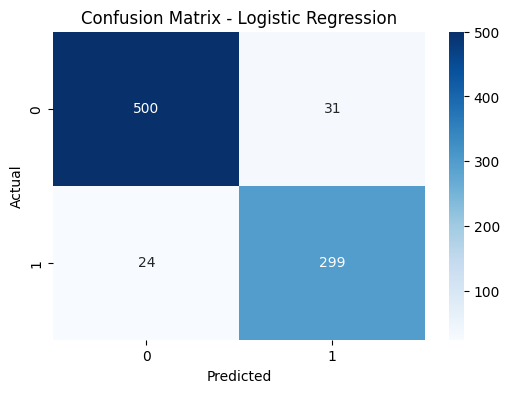

In [21]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nDecision Tree Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.9718969555035128

Decision Tree Report:
               precision    recall  f1-score   support

    Approved       0.97      0.98      0.98       531
    Rejected       0.97      0.95      0.96       323

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_tree)]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.935597
1,Decision Tree,0.971897


In [25]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])

smote_model.fit(X_train, y_train)
y_pred_smote = smote_model.predict(X_test)

print("SMOTE Logistic Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nSMOTE Logistic Report:\n", classification_report(y_test, y_pred_smote))

SMOTE Logistic Accuracy: 0.9320843091334895

SMOTE Logistic Report:
               precision    recall  f1-score   support

    Approved       0.95      0.94      0.95       531
    Rejected       0.91      0.91      0.91       323

    accuracy                           0.93       854
   macro avg       0.93      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854



Among the tested models, the Decision Tree achieved the highest accuracy (97.19%) with strong precision and recall for both classes. Logistic Regression also performed well with balanced metrics. Applying SMOTE did not significantly improve performance, suggesting the dataset did not suffer from severe class imbalance.